# Wide Training Example

In [1]:
import numpy as np
import torch.nn as nn
import torch
import matplotlib.pyplot as plt
import torch.optim as optim
import cv2
from matplotlib.gridspec import GridSpec
from tqdm import tqdm
import os
from torch.utils.data import DataLoader, TensorDataset

In [2]:
def denorm(p, size=960):
    result = np.zeros_like(p)
    result[..., 0] = (p[..., 0] + 1) * (size / 2)
    result[..., 1] = size - ((p[..., 1] + 1) * (size / 2))
    return result

In [3]:
map=cv2.imread('Baarle-Nassau_-_Baarle-Hertog-en no legend.png')[:,:,(2,1,0)]

belgium_color=np.array([251,234,81])
netherlands_color=np.array([255, 255, 228])

netherlands_region=((map-netherlands_color)**2).sum(-1)<50
belgium_region=((map-belgium_color)**2).sum(-1)<10000


b_coords=np.array(np.where(belgium_region)).T.astype('float')
n_coords=np.array(np.where(netherlands_region)).T.astype('float')

#flip and normalize
belgium_coords_all=np.zeros_like(b_coords)
netherlands_coords_all=np.zeros_like(n_coords)

belgium_coords_all[:,0]=b_coords[:,1]/(960/2)-1 #Scale to -1 to 1 for now
belgium_coords_all[:,1]=(960-b_coords[:,0])/(960/2)-1
netherlands_coords_all[:,0]=n_coords[:,1]/(960/2)-1 #Scale to -1 to 1 for now
netherlands_coords_all[:,1]=(960-n_coords[:,0])/(960/2)-1

## Hmm to balance to classes or do more area proportional? Not sure yet. 
np.random.seed(55)
num_points_to_sample=10000 #10000
belgium_coords_sample=belgium_coords_all[np.random.choice(len(belgium_coords_all), num_points_to_sample), :]
netherlands_coords_sample=netherlands_coords_all[np.random.choice(len(netherlands_coords_all), num_points_to_sample), :]
X_sample=np.vstack((netherlands_coords_sample, belgium_coords_sample))
y_sample=np.concatenate((np.zeros(len(belgium_coords_sample)), np.ones(len(netherlands_coords_sample)))).astype('int')
X_sample = torch.FloatTensor(X_sample)
y_sample = torch.tensor(y_sample)

#Skip sampling train on all. 
belgium_coords=belgium_coords_all
netherlands_coords=netherlands_coords_all

X=np.vstack((netherlands_coords, belgium_coords))
y=np.concatenate((np.zeros(len(netherlands_coords)), np.ones(len(belgium_coords)))).astype('int')

X_tensor = torch.FloatTensor(X)
y_tensor = torch.tensor(y)

In [4]:
X_tensor.shape, y_tensor.shape, X_sample.shape, y_sample.shape

(torch.Size([855665, 2]),
 torch.Size([855665]),
 torch.Size([20000, 2]),
 torch.Size([20000]))

In [5]:
class BaarleNet(nn.Module):
    def __init__(self, hidden_layers=[64]):
        super(BaarleNet, self).__init__()
        layers = [nn.Linear(2, hidden_layers[0]), nn.ReLU()]
        for i in range(len(hidden_layers)-1):
            layers.append(nn.Linear(hidden_layers[i], hidden_layers[i+1]))
            layers.append(nn.ReLU())
        layers.append(nn.Linear(hidden_layers[-1], 2))
        self.layers=layers
        self.model = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.model(x)

In [6]:
class BaarleNetLeaky(nn.Module):
    def __init__(self, hidden_layers=[64]):
        super(BaarleNetLeaky, self).__init__()
        layers = [nn.Linear(2, hidden_layers[0]), nn.LeakyReLU()]
        for i in range(len(hidden_layers)-1):
            layers.append(nn.Linear(hidden_layers[i], hidden_layers[i+1]))
            layers.append(nn.LeakyReLU())
        layers.append(nn.Linear(hidden_layers[-1], 2))
        self.layers=layers
        self.model = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.model(x)

In [7]:
def viz_descision_boundary(model, res=256):
    plt.clf()
    fig=plt.figure(0,(6,6))
    ax=fig.add_subplot(111)
    
    probe=np.zeros((res,res,2))
    for j, xx in enumerate(np.linspace(-1, 1, res)):
        for k, yy in enumerate(np.linspace(-1, 1, res)):
            probe[j, k]=[yy,xx]
    probe=probe.reshape(res**2, -1)
    probe_logits=model(torch.tensor(probe, device=next(iter(model.parameters())).device).float())
    probe_logits=probe_logits.numpy(force=True).reshape(res,res,2)
    probe_softmax = torch.nn.Softmax(dim=1)(torch.tensor(probe_logits.reshape(-1, 2)))
    
    ax.imshow(map.mean(2), cmap='gray')
    ax.imshow(np.flipud(np.argmax(probe_logits,2)), 
               extent=[0, 960, 960, 0],  # This maps to image coordinates
               alpha=0.7,
               cmap='viridis')


In [8]:
num_epochs=5
random_seed=25

# 32 Wide

In [ ]:
import torchzero as tz
from light_dataloader import TensorDataLoader
device='cuda'
batch_size = 100_000

torch.manual_seed(random_seed)
X_tensor = torch.FloatTensor(X)
y_tensor = torch.tensor(y)

# Create dataset and dataloader for minibatching
dataset = TensorDataset(X_tensor, y_tensor)
dataloader = [(X_tensor, y_tensor)]

# Initialize model and optimizer
model = BaarleNet([32]).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = tz.Optimizer(
    model.parameters(),
    tz.m.RestartOnStuck(tz.m.ShorR()),
    tz.m.StrongWolfe(a_init='first-order', c2=0.1, fallback=True)
)
num_epochs = 1000

for epoch in range(num_epochs):
    epoch_loss = 0.0
    num_batches = 0

    for batch_X, batch_y in dataloader:
        # Forward pass
        def closure(backward=True):
            outputs = model(batch_X.to(device))
            loss = criterion(outputs, batch_y.to(device))

        # Backward and optimize
            if backward:
                optimizer.zero_grad()
                loss.backward()

            return loss
        loss = optimizer.step(closure)

        epoch_loss += loss.item()
        num_batches += 1

    # Calculate average loss for the epoch
    avg_loss = epoch_loss / num_batches

    if (epoch + 1) % (num_epochs // 10) == 0:
        # Calculate accuracy on full dataset
        with torch.no_grad():
            outputs_batch = model(X_sample.to(device))
            accuracy = (torch.argmax(outputs_batch, dim=1) == y_sample.to(device)).sum().item() / len(y_sample)
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}, Accuracy: {accuracy:.4f}')

Epoch [100/1000], Loss: 0.1838, Accuracy: 0.8629
Epoch [200/1000], Loss: 0.1684, Accuracy: 0.8737
Epoch [300/1000], Loss: 0.1526, Accuracy: 0.8860
Epoch [400/1000], Loss: 0.1486, Accuracy: 0.8940
Epoch [500/1000], Loss: 0.1431, Accuracy: 0.8966
Epoch [600/1000], Loss: 0.1425, Accuracy: 0.8984
Epoch [700/1000], Loss: 0.1424, Accuracy: 0.8984
Epoch [800/1000], Loss: 0.1424, Accuracy: 0.8984
Epoch [900/1000], Loss: 0.1424, Accuracy: 0.8984
Epoch [1000/1000], Loss: 0.1424, Accuracy: 0.8984


<Figure size 640x480 with 0 Axes>

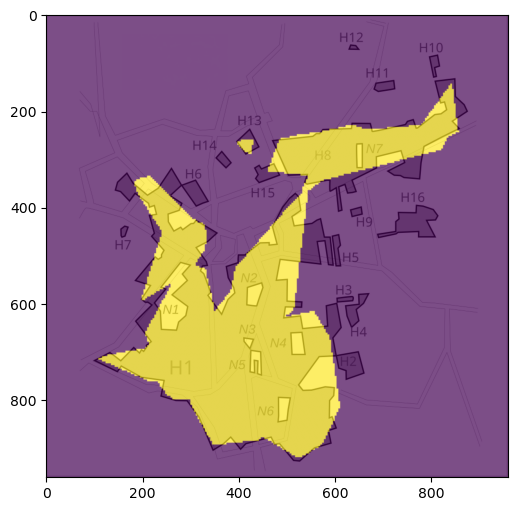

In [12]:
viz_descision_boundary(model)

In [11]:
# torch.save(model.state_dict(), '500 0.9974 ShorR.pth')